# Pretrained checkpoint demo: npy → NIfTI, staggered patch masking & reconstruction

**Paths (edit constants in the next cell):**
- `D:\Cursor\AR-SSL4M-DEMO\cpt\0.pth` — pretrained weights
- `D:\Cursor\AR-SSL4M-DEMO\cpt\AbdomenCT-1K-ImagePart1_Case_00001_0000_0_1.npy` — example volume

**Pipeline**
1. Save npy as `original_from_npy.nii.gz` with **identity affine** (for visualization only, not real scanner geometry).
2. **Patch-level** deterministic **checkerboard (~50%)** occluders: zero `16³` blocks whose grid `(i,j,k)` satisfy `(i+j+k) % 2 == 0` (next row / next slice staggered — no clustered holes like random masks) → `masked_stagger_checkerboard.nii.gz`.
3. Forward pass → **`model_decoder_volume.nii.gz`**: decoder prediction for **every** voxel (`pred_np`), not only holes.
4. **`reconstructed_blend.nii.gz`**: unmasked voxels copied from original npy, masked patches filled from `pred_np`.

**What you should look at**
- **Top row**: **Left** = decoder `pred_np` (raw model output, full volume). **Right** = inpainting blend with red tint on former mask.
- Gray-based panels (**original / pred / blend**) use **the same semi-transparent red** (`MASK_ALPHA`) on masked 16³ voxels. **`masked` input row** keeps **pure red** inside holes (zeros + saturated red).
- **`masked_only_original_highlight.png`**: same slice — grayscale **only inside masked patches** (ground truth), complementary region **solid blue**.
- **`original_slice_unprocessed.png`**: the **same** axial slice **`z=vol.shape[0]//2`**, purely **reference `vol`** (grayscale, `[0,1]` display clip); **no masks, no red/blue**.
- **`mask_swap_original_and_pred_slice.png`**: **one** axial slice (not side-by-side concat). **Masked 16³** voxels show **original intensity**; **unmasked** complement shows **decoder prediction** at the **same** pixel — as if red/blue overlay regions were peeled and filled from the other visualization’s source.
  (This is **not** the same as `reconstructed_blend.nii.gz`, which uses **pred inside holes** and **original outside** — here the roles are **swapped**.)

**Note:** The decoder is run on the whole volume; we only **copy** its output into masked regions for the final image. This repo demo is not for clinical use.

In [35]:
import os
import sys
from pathlib import Path

import numpy as np
import nibabel as nib
import torch

REPO_ROOT = Path(r"D:/Cursor/AR-SSL4M-DEMO").resolve()
CPT_DIR = REPO_ROOT / "cpt"
CKPT_PATH = CPT_DIR / "0.pth"
NPY_PATH = CPT_DIR / "AbdomenCT-1K-ImagePart1_Case_00001_0000_0_1.npy"

OUT_ORIGINAL = CPT_DIR / "original_from_npy.nii.gz"
OUT_MASKED = CPT_DIR / "masked_stagger_checkerboard.nii.gz"
OUT_RECON = CPT_DIR / "reconstructed_blend.nii.gz"
OUT_PRED = CPT_DIR / "model_decoder_volume.nii.gz"

sys.path.insert(0, str(REPO_ROOT / "newFullPretrain"))
from newNewModel import ReconModel

assert NPY_PATH.is_file(), f"Missing npy: {NPY_PATH}"
assert CKPT_PATH.is_file(), f"Missing checkpoint: {CKPT_PATH}"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cuda


In [36]:
vol = np.load(NPY_PATH).astype(np.float32)
assert vol.ndim == 3, f"Expected 3D volume, got shape={vol.shape}"
print("npy shape / dtype / min / max:", vol.shape, vol.dtype, vol.min(), vol.max())

affine = np.eye(4, dtype=np.float32)
nii = nib.Nifti1Image(vol, affine)
nib.save(nii, str(OUT_ORIGINAL))
print("Saved:", OUT_ORIGINAL)

npy shape / dtype / min / max: (128, 128, 128) float32 0.0 1.0
Saved: D:\Cursor\AR-SSL4M-DEMO\cpt\original_from_npy.nii.gz


In [37]:
class ModelCfg:
    hidden_size = 768
    intermediate_size = 3072
    num_attention_heads = 12
    num_key_value_heads = 12
    num_hidden_layers = 12
    img_size = [128, 128, 128]
    patch_size = [16, 16, 16]
    norm_pixel_loss = True
    pos_type = "sincos3d"


def build_prefix_attention_mask(grid_length: int, prefix_length: int, device, dtype=torch.bool):
    """Same prefix-style attention mask as `get_custom_dataset` (prefix_length < grid_length)."""
    L = grid_length + 2
    m = torch.ones(L, L, dtype=dtype, device=device).tril(diagonal=0)
    m[:, : prefix_length + 1] = True
    return m.reshape(-1)


def unpatchify(patchifier, x: torch.Tensor) -> torch.Tensor:
    """x: (B, N, pt*ph*pw) -> (B, 1, D, H, W)"""
    B = x.shape[0]
    pt, ph, pw = patchifier.patch_size
    t, h, w = patchifier.grid_size
    c = 1
    x = x.reshape(B, t, h, w, pt, ph, pw, c)
    x = torch.einsum("nthwpqrc->nctphqwr", x)
    x = x.reshape(B, c, t * pt, h * ph, w * pw)
    return x


def apply_patch_mask_staggered_grid(vol_3d: np.ndarray):
    """Deterministic ~half of patches: zero each 16³ block where (ti+hi+wi) is even.

    Indices (ti, hi, wi) match patchify order; 3D checkerboard staggers adjacent rows/slices."""
    d, h, w = vol_3d.shape
    assert d == h == w == 128, "This demo expects 128³ volume and 16³ patches"
    gt, gh, gw = d // 16, h // 16, w // 16
    masked_ix = set()
    out = vol_3d.copy()
    for ti in range(gt):
        for hi in range(gh):
            for wi in range(gw):
                if (ti + hi + wi) % 2 != 0:
                    continue
                ix = ti * (gh * gw) + hi * gw + wi
                masked_ix.add(ix)
                zs, ys, xs = (
                    slice(ti * 16, (ti + 1) * 16),
                    slice(hi * 16, (hi + 1) * 16),
                    slice(wi * 16, (wi + 1) * 16),
                )
                out[zs, ys, xs] = 0.0
    return out, masked_ix, (gt, gh, gw)


def blend_recon(original: np.ndarray, pred: np.ndarray, masked_ix: set, grid_3d):
    gt, gh, gw = grid_3d
    out = original.copy()
    for ix in masked_ix:
        ti = ix // (gh * gw)
        rem = ix % (gh * gw)
        hi = rem // gw
        wi = rem % gw
        zs, ys, xs = slice(ti * 16, (ti + 1) * 16), slice(hi * 16, (hi + 1) * 16), slice(wi * 16, (wi + 1) * 16)
        out[zs, ys, xs] = pred[zs, ys, xs]
    return out


cfg = ModelCfg()
model = ReconModel(cfg).to(DEVICE)
sd = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
model.load_state_dict(sd, strict=True)
model.eval()
print("Checkpoint loaded.")

Checkpoint loaded.


In [38]:
masked_np, masked_ix, grid_3d = apply_patch_mask_staggered_grid(vol)
nib.save(nib.Nifti1Image(masked_np.astype(np.float32), affine), str(OUT_MASKED))
print("Masked patches:", len(masked_ix), "/", grid_3d[0] * grid_3d[1] * grid_3d[2])
print("Saved:", OUT_MASKED)

grid_length = grid_3d[0] * grid_3d[1] * grid_3d[2]
prefix_length = max(0, min(grid_length - 1, grid_length // 2))

corrupt = torch.from_numpy(masked_np).float().to(DEVICE).unsqueeze(0).unsqueeze(0)
input_ids = torch.tensor([[1] + [3] * grid_length + [2]], dtype=torch.long, device=DEVICE)
att_flat = build_prefix_attention_mask(grid_length, prefix_length, DEVICE)

with torch.no_grad():
    hidden = model.model(
        input_ids=input_ids,
        input_image=corrupt,
        attention_mask=att_flat,
    )[0]
    logits = model.decoder_pred(hidden).float()
    patch_logits = logits[:, :-2, :].contiguous()

    patch_in = model.model.patchifier.patchify(corrupt)
    mean = patch_in.mean(dim=-1, keepdim=True)
    var = patch_in.var(dim=-1, keepdim=True)
    if model.norm_pixel_loss:
        pred_patches = patch_logits * (var + 1.0e-6).sqrt() + mean
    else:
        pred_patches = patch_logits

    pred_vol_t = unpatchify(model.model.patchifier, pred_patches)
    pred_np = pred_vol_t[0, 0].detach().cpu().numpy().astype(np.float32)

nib.save(nib.Nifti1Image(pred_np.astype(np.float32), affine), str(OUT_PRED))
print("Saved model decoder output (full volume prediction):", OUT_PRED, "range:", pred_np.min(), "..", pred_np.max())

recon = blend_recon(vol, pred_np, masked_ix, grid_3d)
nib.save(nib.Nifti1Image(recon.astype(np.float32), affine), str(OUT_RECON))
print("Saved inpainted volume (holes filled, rest original):", OUT_RECON)
print("`recon`: unmasked voxels = original; masked patches = model fill — this is the completed image.")

Masked patches: 256 / 512
Saved: D:\Cursor\AR-SSL4M-DEMO\cpt\masked_stagger_checkerboard.nii.gz
Saved model decoder output (full volume prediction): D:\Cursor\AR-SSL4M-DEMO\cpt\model_decoder_volume.nii.gz range: -0.016436964 .. 1.9456834
Saved inpainted volume (holes filled, rest original): D:\Cursor\AR-SSL4M-DEMO\cpt\reconstructed_blend.nii.gz
`recon`: unmasked voxels = original; masked patches = model fill — this is the completed image.


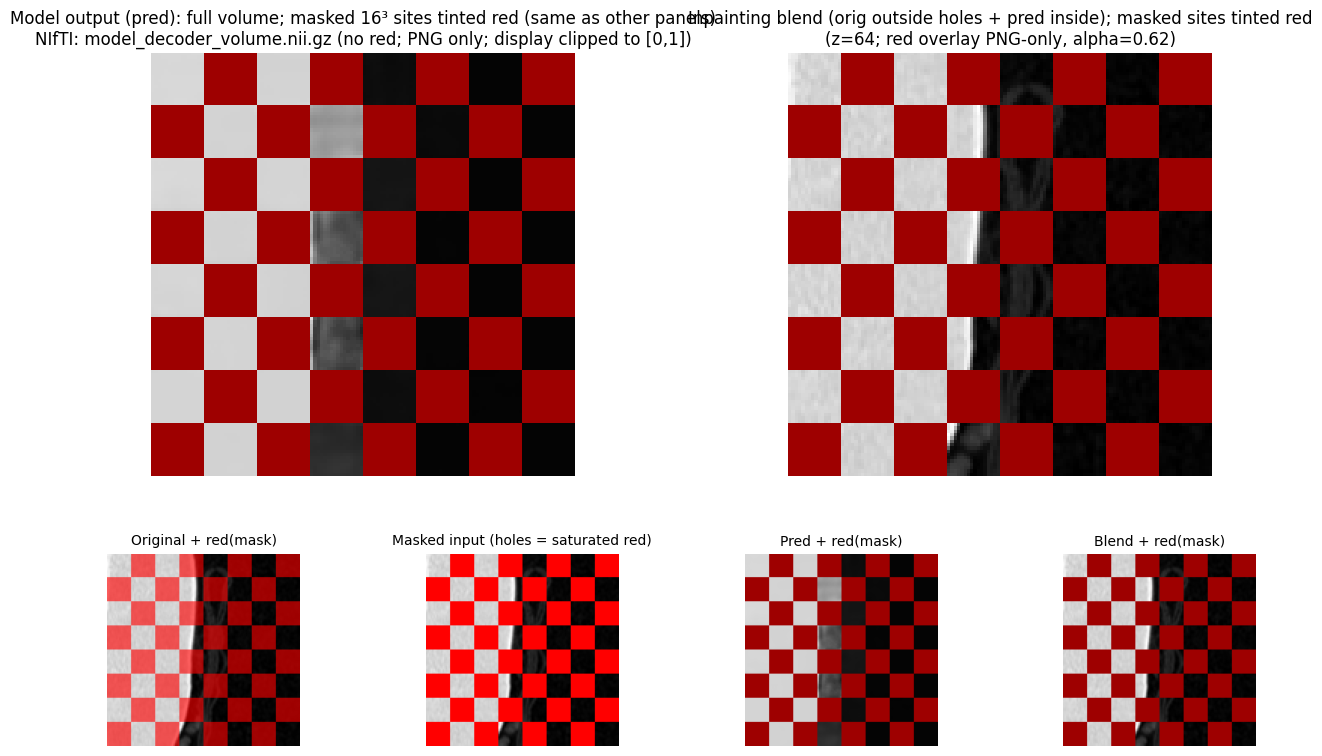

Saved completion figure: D:\Cursor\AR-SSL4M-DEMO\cpt\inpainted_slice_visualization.png


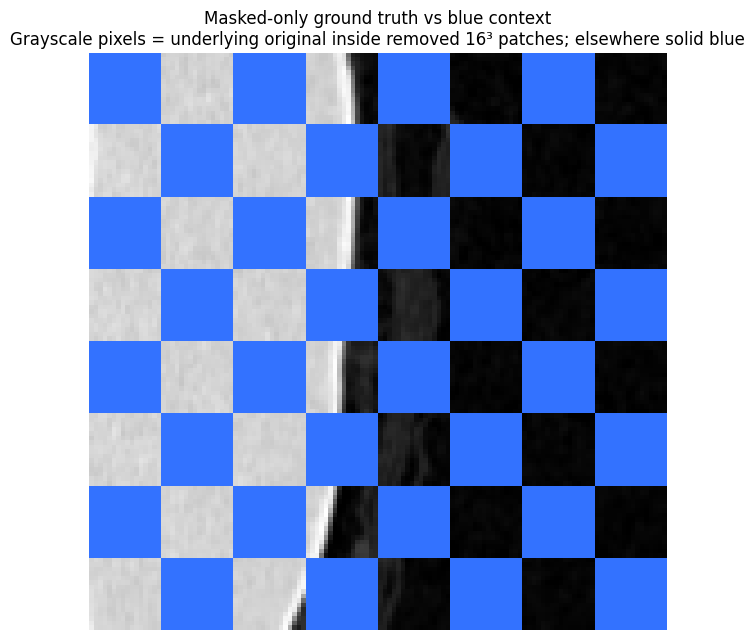

Saved masked-region ground-truth figure: D:\Cursor\AR-SSL4M-DEMO\cpt\masked_only_original_highlight.png


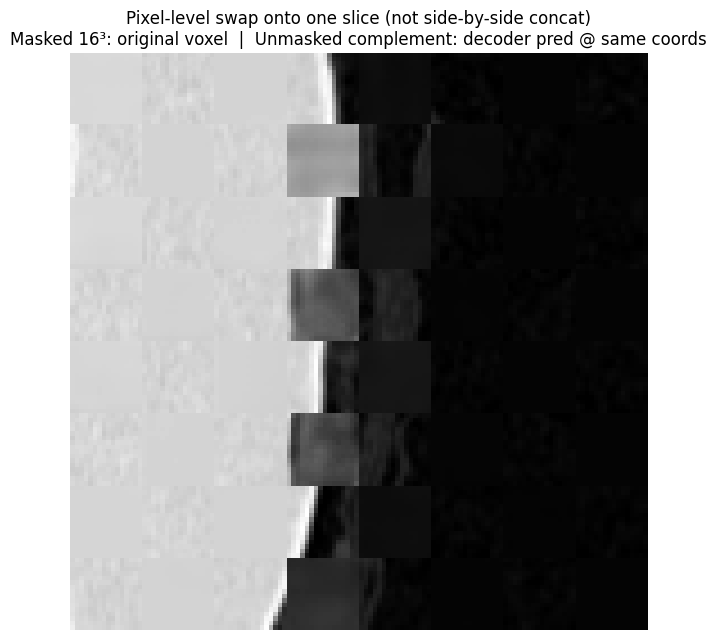

Saved fused pixel-swap figure: D:\Cursor\AR-SSL4M-DEMO\cpt\mask_swap_original_and_pred_slice.png


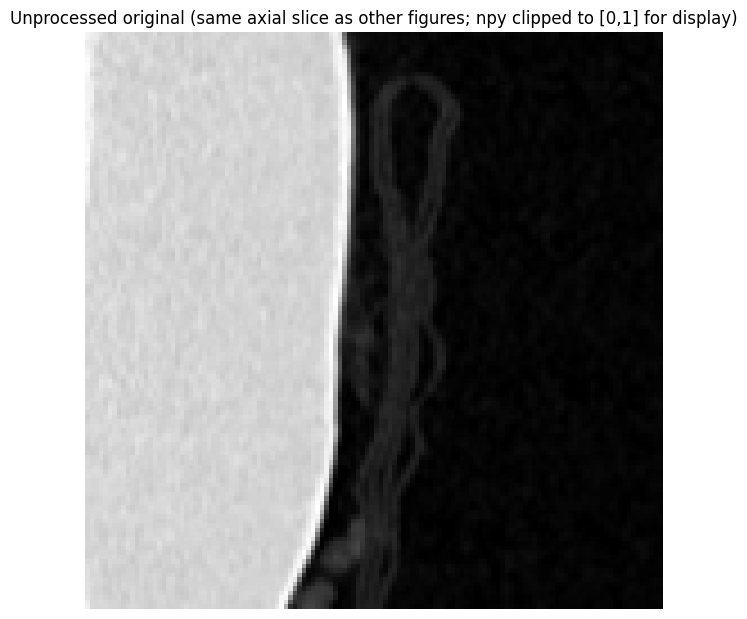

Saved unprocessed-original figure: D:\Cursor\AR-SSL4M-DEMO\cpt\original_slice_unprocessed.png


In [39]:
def _patch_hole_volume(masked_ix: set, grid_3d, shape):
    gt, gh, gw = grid_3d
    m = np.zeros(shape, dtype=bool)
    for ix in masked_ix:
        ti = ix // (gh * gw)
        rem = ix % (gh * gw)
        hi = rem // gw
        wi = rem % gw
        zs = slice(ti * 16, (ti + 1) * 16)
        ys = slice(hi * 16, (hi + 1) * 16)
        xs = slice(wi * 16, (wi + 1) * 16)
        m[zs, ys, xs] = True
    return m


def _gray_slice(arr_3d, sl):
    g = np.clip(arr_3d[sl].T.astype(np.float32), 0.0, 1.0)
    return np.stack([g, g, g], axis=-1)


def _red_holes(rgb_base, hole2d):
    img = rgb_base.copy()
    img[hole2d.astype(bool)] = np.array([1.0, 0.0, 0.0], dtype=np.float32)
    return img


MASK_ALPHA = 0.62  # masked voxels tinted red consistently on grayscale panels

def _red_tint(rgb_base, hole2d, alpha=None):
    """Tint masked locations red (semi-transparent overlay on grayscale)."""
    alpha = MASK_ALPHA if alpha is None else alpha
    h = hole2d.astype(bool)
    rb = rgb_base.astype(np.float32)
    red = np.array([1.0, 0.0, 0.0], dtype=np.float32)
    return np.clip(np.where(h[..., None], (1 - alpha) * rb + alpha * red, rb), 0.0, 1.0)


try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
except ImportError:
    plt = None
    gridspec = None

if plt is not None and gridspec is not None:
    sl = vol.shape[0] // 2

    hole_vol = _patch_hole_volume(masked_ix, grid_3d, vol.shape)
    hole2 = hole_vol[sl].T

    fig = plt.figure(figsize=(16, 9))
    gs = gridspec.GridSpec(2, 4, height_ratios=[2.2, 1], hspace=0.25, wspace=0.12)

    recon_rgb = _red_tint(_gray_slice(recon, sl), hole2)
    pred_rgb = _red_tint(_gray_slice(pred_np, sl), hole2)
    orig_rgb = _red_tint(_gray_slice(vol, sl), hole2)

    ax_m = fig.add_subplot(gs[0, 0:2])
    ax_m.imshow(pred_rgb, origin="lower", vmin=0.0, vmax=1.0)
    ax_m.set_title(
        "Model output (pred): full volume; masked 16³ sites tinted red (same as other panels)\n"
        "NIfTI: model_decoder_volume.nii.gz (no red; PNG only; display clipped to [0,1])"
    )
    ax_m.axis("off")

    ax_big = fig.add_subplot(gs[0, 2:4])
    ax_big.imshow(recon_rgb, origin="lower", vmin=0.0, vmax=1.0)
    ax_big.set_title(
        "Inpainting blend (orig outside holes + pred inside); masked sites tinted red\n"
        f"(z={sl}; red overlay PNG-only, alpha={MASK_ALPHA:.2f})"
    )
    ax_big.axis("off")

    ax0 = fig.add_subplot(gs[1, 0])
    ax0.imshow(orig_rgb, origin="lower", vmin=0, vmax=1)
    ax0.set_title("Original + red(mask)", fontsize=10)
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[1, 1])
    ax1.imshow(_red_holes(_gray_slice(masked_np, sl), hole2), origin="lower", vmin=0, vmax=1)
    ax1.set_title("Masked input (holes = saturated red)", fontsize=10)
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[1, 2])
    ax2.imshow(pred_rgb, origin="lower", vmin=0, vmax=1)
    ax2.set_title("Pred + red(mask)", fontsize=10)
    ax2.axis("off")

    ax3 = fig.add_subplot(gs[1, 3])
    ax3.imshow(recon_rgb, origin="lower", vmin=0, vmax=1)
    ax3.set_title("Blend + red(mask)", fontsize=10)
    ax3.axis("off")

    out_png = CPT_DIR / "inpainted_slice_visualization.png"
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved completion figure:", out_png)

    # --- Focus figure: anatomy that lived inside masked patches; everything else forced blue ---
    g_orig = np.clip(vol[sl].T.astype(np.float32), 0.0, 1.0)
    blue_rgb = np.array([0.2, 0.45, 1.0], dtype=np.float32)
    hc = hole2.astype(bool)
    fc = np.broadcast_to(blue_rgb, (*g_orig.shape, 3)).astype(np.float32).copy()
    mono = np.stack([g_orig, g_orig, g_orig], axis=-1)
    fc = np.where(hc[..., None], mono, fc)

    fig_hl = plt.figure(figsize=(7.5, 7.5))
    ax_hl = fig_hl.add_subplot(1, 1, 1)
    ax_hl.imshow(np.clip(fc, 0.0, 1.0), origin="lower", vmin=0.0, vmax=1.0)
    ax_hl.set_title(
        "Masked-only ground truth vs blue context\n"
        "Grayscale pixels = underlying original inside removed 16³ patches; elsewhere solid blue"
    )
    ax_hl.axis("off")
    out_hl = CPT_DIR / "masked_only_original_highlight.png"
    fig_hl.savefig(out_hl, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved masked-region ground-truth figure:", out_hl)

    # --- Third figure (single slice): masked sites <- original gray; complementary sites <- pred gray ---
    # Matches intent: formerly red-masked patches take original pixels; formerly blue-masked area takes pred pixels.
    g_pred_sl = np.clip(pred_np[sl].T.astype(np.float32), 0.0, 1.0)
    fused = np.where(hc, g_orig, g_pred_sl).astype(np.float32)

    fig_f = plt.figure(figsize=(7.5, 7.5))
    ax_f = fig_f.add_subplot(1, 1, 1)
    ax_f.imshow(fused, cmap="gray", origin="lower", vmin=0.0, vmax=1.0)
    ax_f.set_title(
        "Pixel-level swap onto one slice (not side-by-side concat)\n"
        "Masked 16³: original voxel  |  Unmasked complement: decoder pred @ same coords"
    )
    ax_f.axis("off")
    out_fuse = CPT_DIR / "mask_swap_original_and_pred_slice.png"
    fig_f.savefig(out_fuse, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fused pixel-swap figure:", out_fuse)

    # --- Fourth figure: raw reference slice (same z as other panels), no overlays ---
    g_raw_sl = np.clip(vol[sl].T.astype(np.float32), 0.0, 1.0)
    fig_org = plt.figure(figsize=(7.5, 7.5))
    ax_org = fig_org.add_subplot(1, 1, 1)
    ax_org.imshow(g_raw_sl, cmap="gray", origin="lower", vmin=0.0, vmax=1.0)
    ax_org.set_title("Unprocessed original (same axial slice as other figures; npy clipped to [0,1] for display)")
    ax_org.axis("off")
    out_orgfig = CPT_DIR / "original_slice_unprocessed.png"
    fig_org.savefig(out_orgfig, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved unprocessed-original figure:", out_orgfig)
else:
    print("matplotlib not installed; skipping slice visualization.")